# 01 — Linear & Logistic Regression *from Scratch*

Welcome to the **Foundations** track. You've already built a GPT — but along the way, frameworks did the hard part for you: PyTorch's `.backward()` computed your gradients, and sklearn fit your models. This track goes back and rebuilds that machinery **by hand**, so nothing is magic anymore.

Every model you have ever trained — logistic regression, a CNN, a transformer — is the *same four-step loop*:

1. **Model** — turn inputs into a prediction using parameters.
2. **Loss** — measure how wrong the prediction is with a single number.
3. **Gradient** — ask calculus: *which way do I nudge each parameter to make the loss smaller?*
4. **Update** — take a small step in that direction. Repeat.

In this lesson we build that loop in **pure NumPy** for the two simplest models — linear regression and logistic regression — deriving every gradient ourselves and verifying it two ways: a numerical **gradient check**, and a comparison against scikit-learn. By the end you'll see that **a logistic regression unit *is* a single neuron**, the atom of every network in Lesson 03 onward.

In [1]:
# Pure NumPy + matplotlib only. scikit-learn appears later ONLY to check our work.
import numpy as np
import matplotlib.pyplot as plt

# Fix the random seed so this notebook produces the same numbers every run.
rng = np.random.default_rng(0)

## Part 1: Linear regression — the model

The simplest possible model: predict a number as a straight line of the input,

$$\hat{y} = wx + b$$

where $w$ (the *weight*, the slope) and $b$ (the *bias*, the intercept) are the two parameters we will learn. Let's make synthetic data from a known true line plus noise, so later we can check whether training actually recovers the truth.

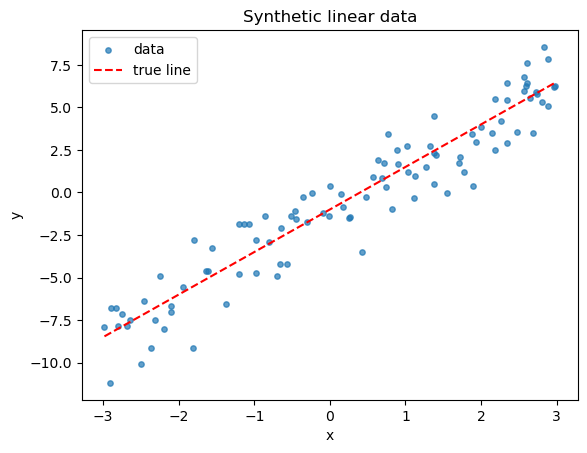

In [2]:
# True parameters we are pretending not to know. Training should recover these.
TRUE_W, TRUE_B = 2.5, -1.0

N = 100                                  # number of data points
x = rng.uniform(-3, 3, size=N)           # inputs spread across [-3, 3]
noise = rng.normal(0, 1.5, size=N)       # measurement noise
y = TRUE_W * x + TRUE_B + noise          # targets: the true line, blurred by noise

def predict(x, w, b):
    """The model: turn input x into a prediction using parameters w, b."""
    return w * x + b

plt.scatter(x, y, s=15, alpha=0.7, label="data")
plt.plot(np.sort(x), predict(np.sort(x), TRUE_W, TRUE_B), "r--", label="true line")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("Synthetic linear data")
plt.show()

## Part 2: The loss (Mean Squared Error), and why

A model needs a *score* for how wrong it is, collapsed to one number we can minimize. For regression the natural choice is **Mean Squared Error**:

$$\text{MSE}(w, b) = \frac{1}{N}\sum_{i=1}^{N}\big(\hat{y}_i - y_i\big)^2$$

We square the errors so positive and negative misses don't cancel, and so big misses are punished disproportionately. Crucially, MSE is a **convex bowl** in the parameters — one global minimum, no traps. Let's *see* that by sweeping the slope $w$ (holding $b$ at the truth) and plotting the loss.

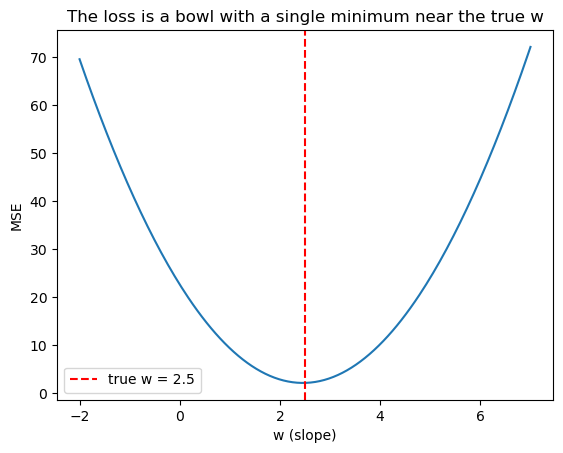

In [3]:
def mse(x, y, w, b):
    """Mean squared error of predictions against targets."""
    err = predict(x, w, b) - y
    return np.mean(err ** 2)

# Sweep w across a range and record the loss at each value.
w_grid = np.linspace(-2, 7, 200)
losses = [mse(x, y, w, TRUE_B) for w in w_grid]

plt.plot(w_grid, losses)
plt.axvline(TRUE_W, color="r", ls="--", label=f"true w = {TRUE_W}")
plt.xlabel("w (slope)"); plt.ylabel("MSE"); plt.legend()
plt.title("The loss is a bowl with a single minimum near the true w")
plt.show()

## Part 3: Deriving the gradient by hand

Gradient descent needs the **gradient** — the partial derivative of the loss with respect to each parameter. Let $r_i = \hat{y}_i - y_i = (wx_i + b) - y_i$ be the residual. Then $\text{MSE} = \frac{1}{N}\sum r_i^2$, and by the chain rule:

$$\frac{\partial \text{MSE}}{\partial w} = \frac{1}{N}\sum_i 2 r_i \frac{\partial r_i}{\partial w} = \frac{2}{N}\sum_i r_i\, x_i$$

$$\frac{\partial \text{MSE}}{\partial b} = \frac{1}{N}\sum_i 2 r_i \frac{\partial r_i}{\partial b} = \frac{2}{N}\sum_i r_i$$

That's the whole of "calculus in machine learning" for this model. Now we implement it — and immediately **check it numerically**. A finite-difference approximation, $\frac{\partial L}{\partial \theta} \approx \frac{L(\theta+\epsilon) - L(\theta-\epsilon)}{2\epsilon}$, needs no calculus and must agree with our formula. This gradient check is the single best habit for trusting from-scratch ML code.

In [4]:
def mse_grad(x, y, w, b):
    """Analytic gradient of MSE w.r.t. (w, b), from the derivation above."""
    r = predict(x, w, b) - y          # residuals
    dw = 2 * np.mean(r * x)
    db = 2 * np.mean(r)
    return dw, db

def numeric_grad(f, w, b, eps=1e-6):
    """Central finite-difference gradient of a scalar function f(w, b)."""
    dw = (f(w + eps, b) - f(w - eps, b)) / (2 * eps)
    db = (f(w, b + eps) - f(w, b - eps)) / (2 * eps)
    return dw, db

# Check at an arbitrary point that the analytic gradient matches the numeric one.
w0, b0 = 0.7, 0.3
ana = mse_grad(x, y, w0, b0)
num = numeric_grad(lambda w, b: mse(x, y, w, b), w0, b0)
print(f"analytic gradient: dw={ana[0]:.8f}, db={ana[1]:.8f}")
print(f"numeric  gradient: dw={num[0]:.8f}, db={num[1]:.8f}")
print(f"max abs difference: {max(abs(ana[0]-num[0]), abs(ana[1]-num[1])):.2e}")

analytic gradient: dw=-11.17014543, db=1.79432070
numeric  gradient: dw=-11.17014543, db=1.79432071
max abs difference: 2.30e-09


## Part 4: Gradient descent from scratch

Now the training loop itself — four lines of real work, repeated:

```
for each step:
    gradient = d(loss)/d(params)        # which way is uphill?
    params   = params - lr * gradient   # step a little downhill
```

The **learning rate** `lr` controls step size. Too small and training crawls; too large and it overshoots and diverges. We'll just pick a sensible value here and study this knob properly in Lesson 02.

learned:  w=2.4673, b=-1.1092
true:     w=2.5, b=-1.0


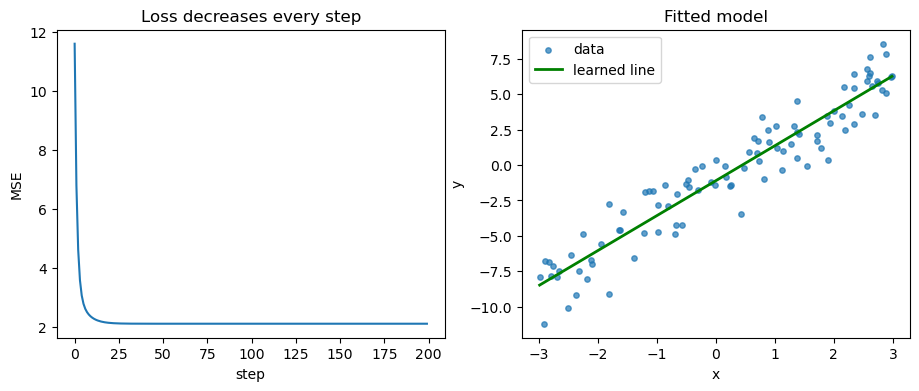

In [5]:
w, b = 0.0, 0.0          # start from nothing — a flat line at zero
lr = 0.05                # learning rate (step size)
steps = 200

loss_history = []
for step in range(steps):
    dw, db = mse_grad(x, y, w, b)   # 1. gradient
    w -= lr * dw                    # 2. step downhill in w
    b -= lr * db                    #    step downhill in b
    loss_history.append(mse(x, y, w, b))

print(f"learned:  w={w:.4f}, b={b:.4f}")
print(f"true:     w={TRUE_W}, b={TRUE_B}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(loss_history); ax1.set_xlabel("step"); ax1.set_ylabel("MSE")
ax1.set_title("Loss decreases every step")
ax2.scatter(x, y, s=15, alpha=0.7, label="data")
ax2.plot(np.sort(x), predict(np.sort(x), w, b), "g-", lw=2, label="learned line")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.legend(); ax2.set_title("Fitted model")
plt.show()

## Part 5: Verify against scikit-learn

We trust the gradient check; now let's confirm the *whole pipeline* by comparing our learned parameters to scikit-learn's `LinearRegression`, which solves the same problem with a direct formula. They should match closely.

In [6]:
from sklearn.linear_model import LinearRegression

sk = LinearRegression().fit(x.reshape(-1, 1), y)
print(f"ours:    w={w:.4f}, b={b:.4f}")
print(f"sklearn: w={sk.coef_[0]:.4f}, b={sk.intercept_:.4f}")

ours:    w=2.4673, b=-1.1092
sklearn: w=2.4673, b=-1.1092


## Part 6: Logistic regression = a single neuron

Now classification: instead of predicting a number, predict the **probability** that an input belongs to class 1. We can't just output $wx+b$ — that's unbounded — so we squash it through the **sigmoid** into $(0, 1)$:

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad \hat{y} = \sigma(\mathbf{w}\cdot\mathbf{x} + b)$$

**This is exactly one neuron**: a weighted sum of inputs, plus a bias, passed through a nonlinear activation. Stack and chain these and you have the neural networks of Lesson 03.

**Why not MSE here?** With the sigmoid, MSE is non-convex and its gradient vanishes when the model is confidently wrong. The right loss is **binary cross-entropy** (a.k.a. log loss):

$$\text{BCE} = -\frac{1}{N}\sum_i \Big[\, y_i \log \hat{y}_i + (1 - y_i)\log(1 - \hat{y}_i) \,\Big]$$

The beautiful payoff: the sigmoid and the log in BCE cancel perfectly when you differentiate, leaving the **same clean gradient form** as linear regression — residual times input:

$$\frac{\partial \text{BCE}}{\partial \mathbf{w}} = \frac{1}{N}\,\mathbf{X}^\top(\hat{\mathbf{y}} - \mathbf{y}), \qquad \frac{\partial \text{BCE}}{\partial b} = \frac{1}{N}\sum_i(\hat{y}_i - y_i)$$

In [7]:
# --- Two-feature synthetic classification data: two Gaussian blobs ---
Nc = 200
X_pos = rng.normal(loc=[ 1.5,  1.5], scale=1.0, size=(Nc // 2, 2))   # class 1
X_neg = rng.normal(loc=[-1.5, -1.5], scale=1.0, size=(Nc // 2, 2))   # class 0
X = np.vstack([X_pos, X_neg])
yc = np.concatenate([np.ones(Nc // 2), np.zeros(Nc // 2)])

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def bce(X, y, w, b):
    p = sigmoid(X @ w + b)
    p = np.clip(p, 1e-12, 1 - 1e-12)        # avoid log(0)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def bce_grad(X, y, w, b):
    """Gradient of BCE: residual times input, just like linear regression."""
    r = sigmoid(X @ w + b) - y              # (predicted prob) - (true label)
    dw = X.T @ r / len(y)
    db = np.mean(r)
    return dw, db

# --- Gradient check for the classifier too ---
w = np.zeros(2); b = 0.0
eps = 1e-6
ana_dw, ana_db = bce_grad(X, yc, w, b)
num_dw0 = (bce(X, yc, w + [eps, 0], b) - bce(X, yc, w - [eps, 0], b)) / (2 * eps)
print(f"BCE gradient check (w[0]): analytic={ana_dw[0]:.8f}, numeric={num_dw0:.8f}")

# --- Train with the same four-step loop ---
lr = 0.5
for step in range(2000):
    dw, db = bce_grad(X, yc, w, b)
    w -= lr * dw
    b -= lr * db

acc = np.mean((sigmoid(X @ w + b) > 0.5) == yc)
print(f"ours:    w={w.round(3)}, b={b:.3f}, accuracy={acc:.3f}")

BCE gradient check (w[0]): analytic=-0.72653591, numeric=-0.72653591
ours:    w=[2.836 2.815], b=0.626, accuracy=0.990


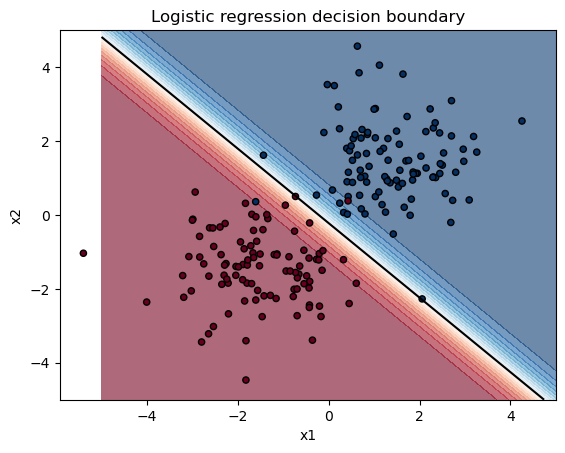

ours:    w=[2.836 2.815], b=0.626
sklearn: w=[2.839 2.819], b=0.627
sklearn accuracy: 0.990


In [8]:
# --- Plot the decision boundary (where predicted probability = 0.5) ---
xx, yy = np.meshgrid(np.linspace(-5, 5, 300), np.linspace(-5, 5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = sigmoid(grid @ w + b).reshape(xx.shape)

plt.contourf(xx, yy, probs, levels=20, cmap="RdBu", alpha=0.6)
plt.contour(xx, yy, probs, levels=[0.5], colors="k")          # the boundary
plt.scatter(X[:, 0], X[:, 1], c=yc, cmap="RdBu", edgecolor="k", s=20)
plt.xlabel("x1"); plt.ylabel("x2"); plt.title("Logistic regression decision boundary")
plt.show()

# --- Verify against scikit-learn ---
# NOTE: sklearn's LogisticRegression applies L2 regularization BY DEFAULT, which
# shrinks the weights. C is the *inverse* regularization strength, so a large C
# makes regularization negligible for an apples-to-apples comparison with our
# unregularized version. (We'll build regularization ourselves in Lesson 05.)
from sklearn.linear_model import LogisticRegression
skc = LogisticRegression(C=1e6).fit(X, yc)
print(f"ours:    w={w.round(3)}, b={b:.3f}")
print(f"sklearn: w={skc.coef_[0].round(3)}, b={skc.intercept_[0]:.3f}")
print(f"sklearn accuracy: {skc.score(X, yc):.3f}")

## Summary

You just built two models with **zero framework magic** — and they were the *same* model in disguise:

- **The universal training loop** is always: **model → loss → gradient → update**, repeated. Linear and logistic regression differ only in the activation (none vs. sigmoid) and the loss (MSE vs. BCE).
- **You derived the gradients yourself** and proved them correct with a finite-difference **gradient check** — the habit that makes from-scratch ML trustworthy.
- Both gradients reduced to the same intuition: **(prediction − target) × input**.
- **Logistic regression is a single neuron.** The only thing standing between this notebook and a deep network is (a) *many* neurons and (b) a way to get gradients through *layers* of them.

**Next:**
- **Lesson 02 — Gradient Descent, deeply:** learning rate, loss surfaces, SGD vs. mini-batch, momentum, and Adam.
- **Lesson 03 — The MLP & Backpropagation:** chain those neurons into layers and derive how the gradient flows backward through all of them.

## Exercises — Try These!

1. **Break it with the learning rate.** In Part 4, set `lr = 1.0` and re-run. What happens to the loss curve, and why? Then find the largest `lr` that still converges.
2. **Add a feature.** Make the linear data depend on two inputs ($y = w_1 x_1 + w_2 x_2 + b$), rewrite `predict`/`mse_grad` with vectors (hint: it looks just like the logistic code), and recover both weights.
3. **Wrong loss on purpose.** Train the *classifier* with MSE instead of BCE. Does it still work? Watch how the gradient behaves when predictions are confidently wrong.
4. **Stretch — multi-class.** Replace the sigmoid with a **softmax** over 3 classes and the BCE with cross-entropy, then classify three blobs. You'll have built the output layer of every classifier network.